In [1]:
import siibra
from nilearn import plotting, image
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import plotly.graph_objects as go
from scipy.interpolate import LinearNDInterpolator
import pandas as pd

[siibra:INFO] Version: 1.0.1-alpha.10
[siibra:WARNING] This is a development release. Use at your own risk.
[siibra:INFO] Please file bugs and issues at https://github.com/FZJ-INM1-BDA/siibra-python.


In [2]:
stn_motor_HDP = nib.load("Publication_Figures/HDP_Pos_Neg.nii")
data_HDP = stn_motor_HDP.get_fdata()
indices_HDP = np.argwhere(data_HDP > 0)
affine_HDP = stn_motor_HDP.affine

In [3]:
#indices_test = np.random.choice(len(indices_HDP), size = 10000)
#voxel_coords_test = indices_HDP[indices_test]
number_points = len(indices_HDP)
ones = np.ones((number_points, 1))
vox_hom = np.hstack([indices_HDP, ones])          # (N,4)
world_points = (affine_HDP @ vox_hom.T).T[:, :3]

In [4]:
print(len(world_points) == len(indices_HDP))

True


# Accessing the HDP

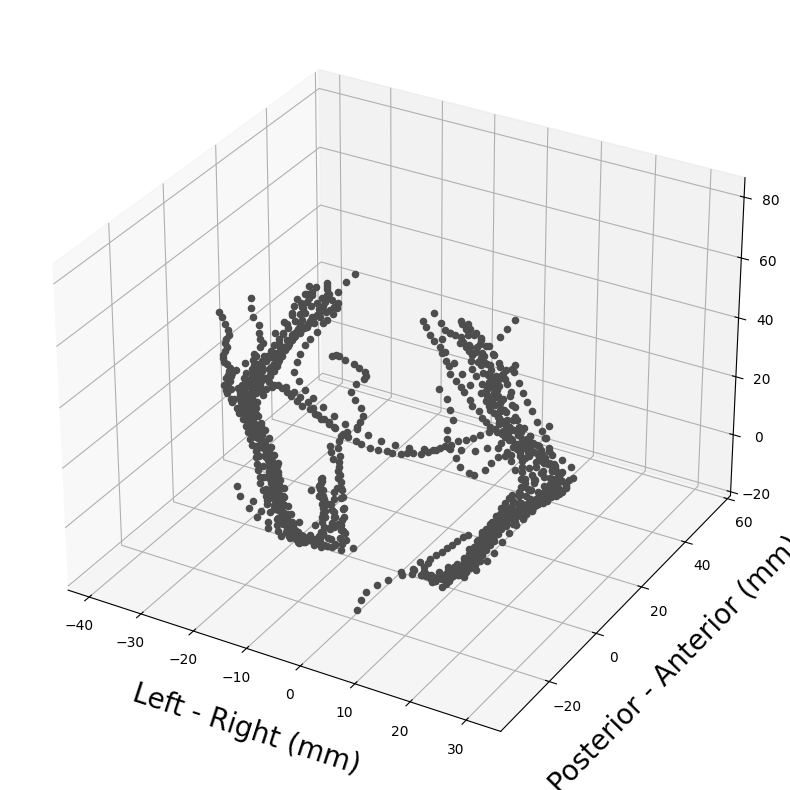

In [5]:
#%matplotlib widget

##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('Left - Right (mm)', fontsize = 20, labelpad = 15)
ax.set_zlabel('Inferior - Anterior (mm)', fontsize = 20, labelpad = 15)
ax.set_ylabel('Posterior - Anterior (mm)', fontsize = 20, labelpad = 15)


##### add in the cortical neurons##############
x_points = world_points[:,0]
y_points = world_points[:,1]
z_points = world_points[:,2]

ax.scatter(x_points, y_points, z_points, c='#4D4D4D', label = "HDP",depthshade=False)
plt.show()

In [9]:
df = pd.DataFrame({"x" : x_points, "y" : y_points, "z" : z_points})
df.to_csv("positions_of_all_HDP_for_Caoimhe_to_query.csv", index=False)

# Julich

In [5]:
parcellation = "JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1"
region = "STN (Subthalamus) right"
coordinate_space = "MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC"

region = siibra.get_region(parcellation, region)

coordinate_space = region.spaces.get(coordinate_space)

region_map = region.get_regional_map(coordinate_space, maptype="statistical")
NIfTI_region = region_map.fetch()
region_data = NIfTI_region.get_fdata()
affine = NIfTI_region.affine

## Get voxel indices (i,j,k) of valid voxels
region_data_indices = np.argwhere(region_data > 0)

ones = np.ones((len(region_data_indices), 1))
vox_hom = np.hstack([region_data_indices, ones])          # (N,4)
world_points = (affine @ vox_hom.T).T[:, :3]

Loading preconfigured Map instances: 100%|████████████████████████████████████████████| 59/59 [00:00<00:00, 150.37Map/s]
[siibra:WARNING] Map registry contains multiple classes: Map, SparseMap


In [6]:
print(len(world_points) == len(region_data_indices))

True


In [7]:
len(region_data_indices)

1261

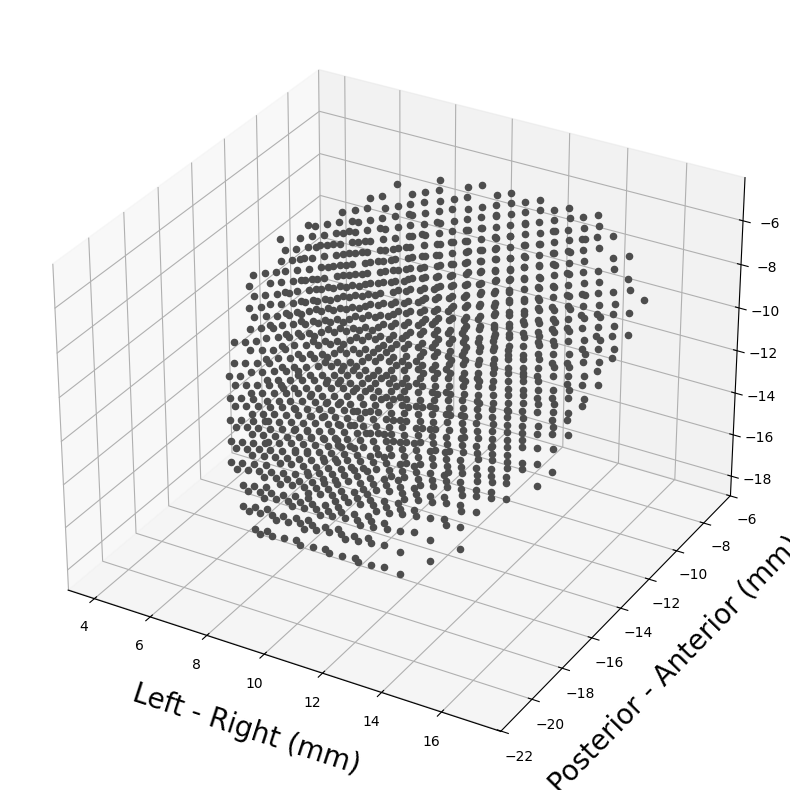

In [8]:
#%matplotlib widget

##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('Left - Right (mm)', fontsize = 20, labelpad = 15)
ax.set_zlabel('Inferior - Anterior (mm)', fontsize = 20, labelpad = 15)
ax.set_ylabel('Posterior - Anterior (mm)', fontsize = 20, labelpad = 15)


##### add in the cortical neurons##############
x_points = world_points[:,0]
y_points = world_points[:,1]
z_points = world_points[:,2]

ax.scatter(x_points, y_points, z_points, c='#4D4D4D', label = "HDP",depthshade=False)
plt.show()

In [9]:
df = pd.DataFrame({"x" : x_points, "y" : y_points, "z" : z_points})
df.to_csv("positions_of_all_julich_for_Caoimhe_to_query.csv", index=False)